Required Libraries
1. biopython - BLOSUM62 reference matrix and comparison aligner
2. numpy - Dynamic-programming matrices
3. matplotlib - Score-matrix visualization
4. pandas - Optional benchmark tables

In [3]:
!pip install -q biopython numpy matplotlib pandas

setup Verification

In [2]:
import sys
import Bio
import numpy as np
import matplotlib
import pandas as pd

print("Python:", sys.version)
print("BioPython:", Bio.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Pandas:", pd.__version__)

print("\nSetup completed successfully.")

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
BioPython: 1.88
NumPy: 2.1.3
Matplotlib: 3.10.0
Pandas: 2.2.3

Setup completed successfully.


required modules

In [4]:
from dataclasses import dataclass
from typing import Dict

import numpy as np
import matplotlib.pyplot as plt

from Bio import Align
from Bio.Align import PairwiseAligner
from Bio.Align import substitution_matrices

In [12]:
blosum62 = substitution_matrices.load("BLOSUM62")

print("BLOSUM62 loaded successfully")
print("Score A-A:", blosum62["A", "A"])
print("Score A-R:", blosum62["A", "R"])
print("Score W-W:", blosum62["W", "W"])
print("Score W-Q:", blosum62["W", "Q"])

sequence_a = "HEAGAWGHEE"
sequence_b = "PAWHEAE"

BLOSUM62 loaded successfully
Score A-A: 4.0
Score A-R: -1.0
Score W-W: 11.0
Score W-Q: -2.0


result structure

this stores the:
- The aligned first sequence

- The aligned second sequence

- The final alignment score

- The combined score matrix

- The three affine-gap matrices

In [13]:
@dataclass
class AlignmentResult:
    aligned_a: str
    aligned_b: str
    score: float
    score_matrix: np.ndarray
    matrices: Dict[str, np.ndarray]


helper function for selecting the maximum

In [14]:
def _argmax(values):
    best_index = max(range(len(values)), key=lambda i: values[i])
    return values[best_index], best_index

custom aligner

this cell supports both algorithms for:

- mode="global": Needleman–Wunsch

- mode="local": Smith–Waterman

In [15]:
def align_affine(
    sequence_a: str,
    sequence_b: str,
    substitution_matrix,
    gap_open: float,
    gap_extend: float,
    mode: str = "global",
) -> AlignmentResult:

    if mode not in {"global", "local"}:
        raise ValueError("mode must be 'global' or 'local'")

    sequence_a = sequence_a.upper()
    sequence_b = sequence_b.upper()

    n = len(sequence_a)
    m = len(sequence_b)

    negative_infinity = -np.inf

    # M: alignment ends with two aligned characters
    # X: alignment ends with a gap in sequence B
    # Y: alignment ends with a gap in sequence A
    matrix_m = np.full((n + 1, m + 1), negative_infinity)
    matrix_x = np.full((n + 1, m + 1), negative_infinity)
    matrix_y = np.full((n + 1, m + 1), negative_infinity)

    pointer_m = np.full((n + 1, m + 1), "", dtype=object)
    pointer_x = np.full((n + 1, m + 1), "", dtype=object)
    pointer_y = np.full((n + 1, m + 1), "", dtype=object)

    matrix_m[0, 0] = 0.0

    if mode == "local":
        matrix_m[:, :] = 0.0
        matrix_x[:, :] = 0.0
        matrix_y[:, :] = 0.0

    else:
        for i in range(1, n + 1):
            matrix_x[i, 0] = -gap_open - (i - 1) * gap_extend
            pointer_x[i, 0] = "X" if i > 1 else ""

        for j in range(1, m + 1):
            matrix_y[0, j] = -gap_open - (j - 1) * gap_extend
            pointer_y[0, j] = "Y" if j > 1 else ""

    for i in range(1, n + 1):
        for j in range(1, m + 1):

            substitution_score = substitution_matrix[
                sequence_a[i - 1],
                sequence_b[j - 1],
            ]

            previous_values = [
                matrix_m[i - 1, j - 1],
                matrix_x[i - 1, j - 1],
                matrix_y[i - 1, j - 1],
            ]

            best_previous, previous_state = _argmax(previous_values)
            candidate_m = best_previous + substitution_score

            if mode == "local" and candidate_m < 0:
                matrix_m[i, j] = 0.0
                pointer_m[i, j] = ""
            else:
                matrix_m[i, j] = candidate_m
                pointer_m[i, j] = ("M", "X", "Y")[previous_state]

            opening_x = matrix_m[i - 1, j] - gap_open
            extending_x = matrix_x[i - 1, j] - gap_extend

            if mode == "local":
                x_values = [0.0, opening_x, extending_x]
                best_x, x_state = _argmax(x_values)
                matrix_x[i, j] = best_x
                pointer_x[i, j] = ("", "M", "X")[x_state]
            else:
                if opening_x >= extending_x:
                    matrix_x[i, j] = opening_x
                    pointer_x[i, j] = "M"
                else:
                    matrix_x[i, j] = extending_x
                    pointer_x[i, j] = "X"

            opening_y = matrix_m[i, j - 1] - gap_open
            extending_y = matrix_y[i, j - 1] - gap_extend

            if mode == "local":
                y_values = [0.0, opening_y, extending_y]
                best_y, y_state = _argmax(y_values)
                matrix_y[i, j] = best_y
                pointer_y[i, j] = ("", "M", "Y")[y_state]
            else:
                if opening_y >= extending_y:
                    matrix_y[i, j] = opening_y
                    pointer_y[i, j] = "M"
                else:
                    matrix_y[i, j] = extending_y
                    pointer_y[i, j] = "Y"

    if mode == "global":
        final_values = [
            matrix_m[n, m],
            matrix_x[n, m],
            matrix_y[n, m],
        ]

        score, final_state_index = _argmax(final_values)
        final_state = ("M", "X", "Y")[final_state_index]

        end_i, end_j = n, m

    else:
        combined = np.maximum.reduce([
            matrix_m,
            matrix_x,
            matrix_y,
        ])

        end_i, end_j = np.unravel_index(
            np.argmax(combined),
            combined.shape,
        )

        score = combined[end_i, end_j]

        state_values = [
            matrix_m[end_i, end_j],
            matrix_x[end_i, end_j],
            matrix_y[end_i, end_j],
        ]

        _, final_state_index = _argmax(state_values)
        final_state = ("M", "X", "Y")[final_state_index]

    aligned_a = []
    aligned_b = []

    i, j, state = end_i, end_j, final_state

    while i > 0 or j > 0:

        if mode == "local":
            current_score = {
                "M": matrix_m[i, j],
                "X": matrix_x[i, j],
                "Y": matrix_y[i, j],
            }[state]

            if current_score <= 0:
                break

        if state == "M":
            if i == 0 or j == 0:
                break

            aligned_a.append(sequence_a[i - 1])
            aligned_b.append(sequence_b[j - 1])

            previous_state = pointer_m[i, j]

            i -= 1
            j -= 1
            state = previous_state

        elif state == "X":
            if i == 0:
                break

            aligned_a.append(sequence_a[i - 1])
            aligned_b.append("-")

            previous_state = pointer_x[i, j]

            i -= 1

            if previous_state == "":
                break

            state = previous_state

        elif state == "Y":
            if j == 0:
                break

            aligned_a.append("-")
            aligned_b.append(sequence_b[j - 1])

            previous_state = pointer_y[i, j]

            j -= 1

            if previous_state == "":
                break

            state = previous_state

        else:
            raise RuntimeError(f"Unknown traceback state: {state}")

    aligned_a.reverse()
    aligned_b.reverse()

    score_matrix = np.maximum.reduce([
        matrix_m,
        matrix_x,
        matrix_y,
    ])

    return AlignmentResult(
        aligned_a="".join(aligned_a),
        aligned_b="".join(aligned_b),
        score=float(score),
        score_matrix=score_matrix,
        matrices={
            "M": matrix_m,
            "X": matrix_x,
            "Y": matrix_y,
        },
    )

test sequences and penalties

The gap cost used by the implementation is:


go + (k−1)ge
where k is the gap length.


In [16]:
sequence_a = "HEAGAWGHEE"
sequence_b = "PAWHEAE"

gap_open = 10
gap_extend = 0.5

needleman–wunsch

In [17]:
global_result = align_affine(
    sequence_a=sequence_a,
    sequence_b=sequence_b,
    substitution_matrix=blosum62,
    gap_open=gap_open,
    gap_extend=gap_extend,
    mode="global",
)

print("Needleman-Wunsch global alignment")
print("Score:", global_result.score)
print(global_result.aligned_a)
print(global_result.aligned_b)

Needleman-Wunsch global alignment
Score: 4.0
HEAGAWGHEE
---PAWHEAE


smith-waterman

In [18]:
local_result = align_affine(
    sequence_a=sequence_a,
    sequence_b=sequence_b,
    substitution_matrix=blosum62,
    gap_open=gap_open,
    gap_extend=gap_extend,
    mode="local",
)

print("Smith-Waterman local alignment")
print("Score:", local_result.score)
print(local_result.aligned_a)
print(local_result.aligned_b)

Smith-Waterman local alignment
Score: 18.0
AWGHE
AW-HE


displaying the dynamic programming matrices

In [19]:
print("Needleman-Wunsch combined matrix:")
print(global_result.score_matrix)

print("\nSmith-Waterman combined matrix:")
print(local_result.score_matrix)

Needleman-Wunsch combined matrix:
[[  0.  -10.  -10.5 -11.  -11.5 -12.  -12.5 -13. ]
 [-10.   -2.  -12.  -12.5  -3.  -11.5 -13.5 -12.5]
 [-10.5 -11.   -3.  -13.  -12.5   2.   -8.   -8.5]
 [-11.  -11.5  -7.   -6.  -13.5  -8.    6.   -4. ]
 [-11.5 -13.  -11.5  -9.   -8.   -8.5  -4.    4. ]
 [-12.  -12.5  -9.  -14.5 -11.   -9.   -4.5  -5. ]
 [-12.5 -14.  -14.5   2.   -8.   -8.5  -5.   -6.5]
 [-13.  -14.5 -14.   -8.    0.  -10.   -5.5  -7. ]
 [-13.5 -15.  -15.5  -8.5   0.    0.   -6.   -5.5]
 [-14.  -14.5 -16.   -9.   -8.5   5.   -1.   -1. ]
 [-14.5 -15.  -15.5  -9.5  -9.   -3.5   4.    4. ]]

Smith-Waterman combined matrix:
[[ 0.   0.   0.   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   8.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.  13.   3.   5. ]
 [ 0.   0.   4.   0.   0.   3.  17.   7. ]
 [ 0.   0.   0.   2.   0.   2.5  7.  15. ]
 [ 0.   0.   4.   0.   0.   2.   6.5  6. ]
 [ 0.   0.   0.  15.   5.   4.5  6.   4.5]
 [ 0.   0.   0.   5.  13.   3.   5.5  4. ]
 [ 0.   0.   0.   4.5 13.  

individual affinegap matrices

In [20]:
print("M matrix:")
print(global_result.matrices["M"])

print("X matrix:")
print(global_result.matrices["X"])

print("Y matrix:")
print(global_result.matrices["Y"])

M matrix:
[[  0.   -inf  -inf  -inf  -inf  -inf  -inf  -inf]
 [ -inf  -2.  -12.  -12.5  -3.  -11.5 -14.  -12.5]
 [ -inf -11.   -3.  -15.  -12.5   2.  -12.5  -8.5]
 [ -inf -11.5  -7.   -6.  -15.  -13.5   6.   -9. ]
 [ -inf -13.  -11.5  -9.   -8.  -15.5  -8.    4. ]
 [ -inf -12.5  -9.  -14.5 -11.   -9.   -4.5  -5. ]
 [ -inf -16.  -15.5   2.  -16.5 -14.  -12.   -7.5]
 [ -inf -14.5 -14.  -16.5   0.  -10.   -8.5  -7. ]
 [ -inf -15.  -16.5 -16.    0.    0.  -12.   -5.5]
 [ -inf -14.5 -16.  -18.5  -8.5   5.   -1.   -1. ]
 [ -inf -15.  -15.5 -19.   -9.   -3.5   4.    4. ]]
X matrix:
[[ -inf  -inf  -inf  -inf  -inf  -inf  -inf  -inf]
 [-10.   -inf  -inf  -inf  -inf  -inf  -inf  -inf]
 [-10.5 -12.  -22.  -22.5 -13.  -21.5 -24.  -22.5]
 [-11.  -12.5 -13.  -23.  -13.5  -8.  -22.5 -18.5]
 [-11.5 -13.  -13.5 -16.  -14.   -8.5  -4.  -19. ]
 [-12.  -13.5 -14.  -16.5 -14.5  -9.   -4.5  -6. ]
 [-12.5 -14.  -14.5 -17.  -15.   -9.5  -5.   -6.5]
 [-13.  -14.5 -15.   -8.  -15.5 -10.   -5.5  -7. ]
 [-13.5 -1

plotting the score matrices

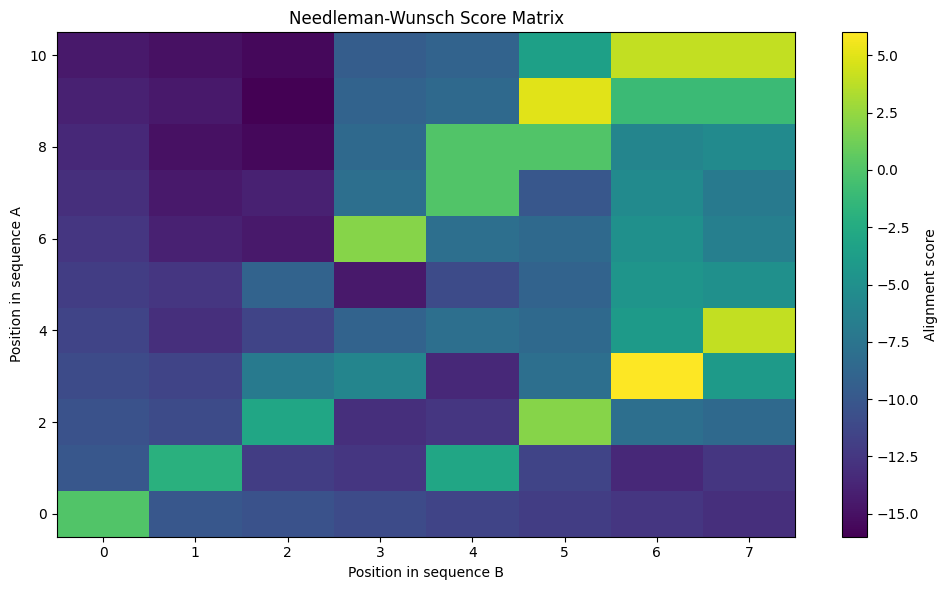

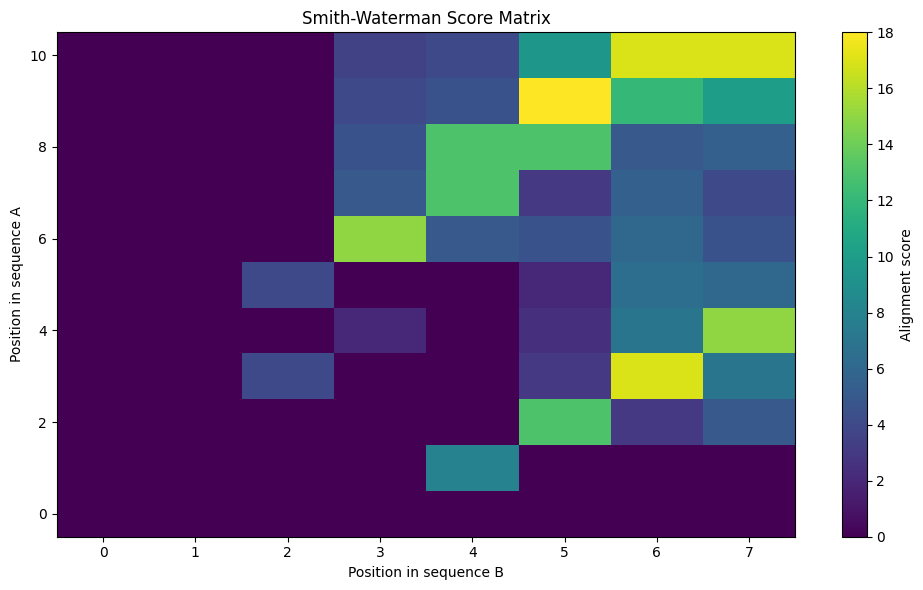

In [21]:
def plot_score_matrix(result, title):
    plt.figure(figsize=(10, 6))

    plt.imshow(
        result.score_matrix,
        origin="lower",
        aspect="auto",
        cmap="viridis",
    )

    plt.colorbar(label="Alignment score")
    plt.xlabel("Position in sequence B")
    plt.ylabel("Position in sequence A")
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_score_matrix(
    global_result,
    "Needleman-Wunsch Score Matrix",
)

plot_score_matrix(
    local_result,
    "Smith-Waterman Score Matrix",
)

biopython global aligner configuration

In [22]:
biopython_global = PairwiseAligner()

biopython_global.mode = "global"
biopython_global.substitution_matrix = blosum62
biopython_global.open_gap_score = -gap_open
biopython_global.extend_gap_score = -gap_extend

biopython_global_score = biopython_global.score(
    sequence_a,
    sequence_b,
)

print("Custom global score:", global_result.score)
print("BioPython global score:", biopython_global_score)

Custom global score: 4.0
BioPython global score: 4.0


In [23]:
biopython_local = PairwiseAligner()

biopython_local.mode = "local"
biopython_local.substitution_matrix = blosum62
biopython_local.open_gap_score = -gap_open
biopython_local.extend_gap_score = -gap_extend

biopython_local_score = biopython_local.score(
    sequence_a,
    sequence_b,
)

print("Custom local score:", local_result.score)
print("BioPython local score:", biopython_local_score)

Custom local score: 18.0
BioPython local score: 18.0


In [24]:
assert abs(
    global_result.score - biopython_global_score
) < 1e-6

assert abs(
    local_result.score - biopython_local_score
) < 1e-6

print("Both custom scores match BioPython.")

Both custom scores match BioPython.


testing multiple sequence pairs

BLOSUM62 is designed for protein sequences. For nucleotide sequences such as `"GATTACA"`, a DNA-specific scoring scheme is more biologically appropriate.

In [26]:
test_cases = [
    ("HEAGAWGHEE", "PAWHEAE"),
    ("MKWVTFISLL", "MKWVTFIS"),
    ("GATTACA", "GCATGCA"),  # Changed 'GCATGCU' to 'GCATGCA' to use only DNA bases (A, C, G, T)
    ("AAAAAAA", "AAA"),
    ("ACDEFGHIK", "ACDFGHIK"),
]

for sequence_a, sequence_b in test_cases:

    for mode in ["global", "local"]:

        custom_result = align_affine(
            sequence_a,
            sequence_b,
            blosum62,
            gap_open,
            gap_extend,
            mode,
        )

        aligner = PairwiseAligner()
        aligner.mode = mode
        aligner.substitution_matrix = blosum62
        aligner.open_gap_score = -gap_open
        aligner.extend_gap_score = -gap_extend

        reference_score = aligner.score(
            sequence_a,
            sequence_b,
        )

        difference = abs(
            custom_result.score - reference_score
        )

        print(
            mode,
            sequence_a,
            sequence_b,
            "custom =", custom_result.score,
            "BioPython =", reference_score,
            "difference =", difference,
        )

        assert difference < 1e-6

print("All correctness tests passed.")

global HEAGAWGHEE PAWHEAE custom = 4.0 BioPython = 4.0 difference = 0.0
local HEAGAWGHEE PAWHEAE custom = 18.0 BioPython = 18.0 difference = 0.0
global MKWVTFISLL MKWVTFIS custom = 33.5 BioPython = 33.5 difference = 0.0
local MKWVTFISLL MKWVTFIS custom = 44.0 BioPython = 44.0 difference = 0.0
global GATTACA GCATGCA custom = 24.0 BioPython = 24.0 difference = 0.0
local GATTACA GCATGCA custom = 24.0 BioPython = 24.0 difference = 0.0
global AAAAAAA AAA custom = 0.5 BioPython = 0.5 difference = 0.0
local AAAAAAA AAA custom = 12.0 BioPython = 12.0 difference = 0.0
global ACDEFGHIK ACDFGHIK custom = 38.0 BioPython = 38.0 difference = 0.0
local ACDEFGHIK ACDFGHIK custom = 38.0 BioPython = 38.0 difference = 0.0
All correctness tests passed.


In [27]:
import random

def random_protein(length):
    amino_acids = "ACDEFGHIKLMNPQRSTVWY"
    return "".join(
        random.choice(amino_acids)
        for _ in range(length)
    )

In [30]:
import time

benchmark_lengths = [50, 100, 200, 300, 500]
benchmark_rows = []

for length in benchmark_lengths:

    sequence_a = random_protein(length)
    sequence_b = random_protein(length)

    start = time.perf_counter()

    custom_result = align_affine(
        sequence_a,
        sequence_b,
        blosum62,
        gap_open,
        gap_extend,
        mode="global",
    )

    custom_time = time.perf_counter() - start

    start = time.perf_counter()

    reference_score = biopython_global.score(
        sequence_a,
        sequence_b,
    )

    biopython_time = time.perf_counter() - start

    benchmark_rows.append({
        "length": length,
        "custom_score": custom_result.score,
        "biopython_score": reference_score,
        "scores_match": abs(
            custom_result.score - reference_score
        ) < 1e-6,
        "custom_time_seconds": custom_time,
        "biopython_time_seconds": biopython_time,
    })

benchmark_table = pd.DataFrame(benchmark_rows)
benchmark_table

,length,custom_score,biopython_score,scores_match,custom_time_seconds,biopython_time_seconds
0,50,-14.0,-14.0,True,0.016904,0.000111
1,100,-5.5,-5.5,True,0.060055,0.000112
2,200,-3.5,-3.5,True,0.222257,0.000293
3,300,4.0,4.0,True,0.501277,0.000532
4,500,-18.0,-18.0,True,1.429444,0.001291


In [29]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=benchmark_table)

https://docs.google.com/spreadsheets/d/1S-aJdwGpu2NKPyVK34AlSwvAC_d27_1RNHC5XqWCzg4/edit#gid=0


benchmark timings

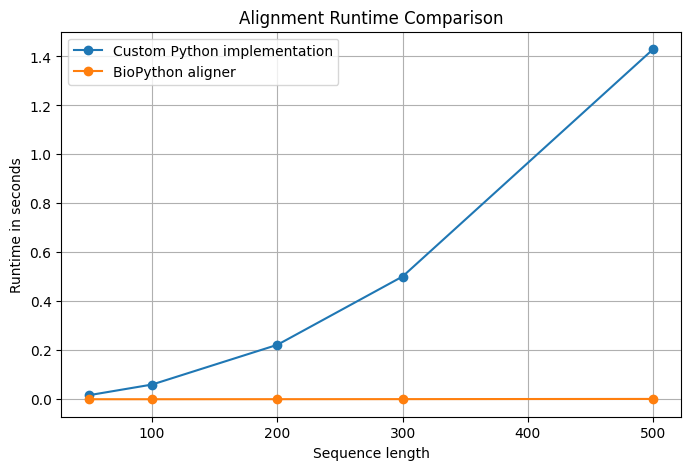

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    benchmark_table["length"],
    benchmark_table["custom_time_seconds"],
    marker="o",
    label="Custom Python implementation",
)

plt.plot(
    benchmark_table["length"],
    benchmark_table["biopython_time_seconds"],
    marker="o",
    label="BioPython aligner",
)

plt.xlabel("Sequence length")
plt.ylabel("Runtime in seconds")
plt.title("Alignment Runtime Comparison")
plt.legend()
plt.grid(True)
plt.show()

custom substitution matrix

In [33]:
class DictionaryMatrix:
    def __init__(self, values, default=-1):
        self.values = values
        self.default = default

    def __getitem__(self, key):
        return self.values.get(key, self.default)


custom_matrix = DictionaryMatrix({
    ("A", "A"): 2,
    ("A", "C"): -1,
    ("C", "A"): -1,
    ("C", "C"): 2,
})

custom_result = align_affine(
    sequence_a="AACAC",
    sequence_b="ACAC",
    substitution_matrix=custom_matrix,
    gap_open=3,
    gap_extend=1,
    mode="global",
)

print("Score:", custom_result.score)
print(custom_result.aligned_a)
print(custom_result.aligned_b)

Score: 5.0
AACAC
-ACAC
